# Folding HMM Statistical Plots

Read the local downloaded eval result CSV and generate:

- p-parameter sweep plots for wall time, GPU memory, and accuracy metrics
- homolog-count sweep plots for wall time, GPU memory, and accuracy metrics

This notebook uses `/Users/chencheng-lin/Downloads/eval_result/folding_hmm_eval_result.csv` by default, filters to the 100 test-set-2 proteins listed in `testset_compaare.md`, and saves plots/tables under `prostT5/stat asset`.


In [24]:
#@title Configure local input/output paths
from pathlib import Path

EVAL_RESULT_DIR = Path('/Users/chencheng-lin/Downloads/eval_result-2')
RESULT_CSV = EVAL_RESULT_DIR / 'folding_hmm_eval_result.csv'
TESTSET_COMPARE_MD = Path('/Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/testset_compaare.md')
SUCCESS_COUNTS_CSV = EVAL_RESULT_DIR / 'test_set_2_homolog_success_counts.csv'
FOLDING_MSA_DIR = Path('/Users/chencheng-lin/Desktop/folding_MSA-2')
OUT_DIR = Path('/Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset')

if not RESULT_CSV.exists():
    raise FileNotFoundError(f'Result CSV not found: {RESULT_CSV}')
if not TESTSET_COMPARE_MD.exists():
    raise FileNotFoundError(f'Test-set comparison markdown not found: {TESTSET_COMPARE_MD}')
if not FOLDING_MSA_DIR.exists():
    raise FileNotFoundError(f'Folding MSA directory not found: {FOLDING_MSA_DIR}')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('RESULT_CSV:', RESULT_CSV)
print('TESTSET_COMPARE_MD:', TESTSET_COMPARE_MD)
print('SUCCESS_COUNTS_CSV:', SUCCESS_COUNTS_CSV if SUCCESS_COUNTS_CSV.exists() else 'not found')
print('FOLDING_MSA_DIR:', FOLDING_MSA_DIR)
print('OUT_DIR:', OUT_DIR)


RESULT_CSV: /Users/chencheng-lin/Downloads/eval_result-2/folding_hmm_eval_result.csv
TESTSET_COMPARE_MD: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/testset_compaare.md
SUCCESS_COUNTS_CSV: /Users/chencheng-lin/Downloads/eval_result-2/test_set_2_homolog_success_counts.csv
FOLDING_MSA_DIR: /Users/chencheng-lin/Desktop/folding_MSA-2
OUT_DIR: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset


In [25]:
#@title Imports and plotting style
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from scipy import stats
except Exception:
    stats = None

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
print('pandas:', pd.__version__)
print('scipy available:', stats is not None)
print('seaborn available:', sns is not None)


pandas: 2.2.3
scipy available: True
seaborn available: False


In [26]:
#@title Load CSV and filter to test set 2 proteins with 64 homologs
import csv


def read_test_set_2_ids(path: Path):
    text = path.read_text()
    marker = '## Test Set 2 Protein Lengths'
    if marker not in text:
        raise ValueError(f'Could not find {marker!r} in {path}')
    section = text.split(marker, 1)[1]
    ids = []
    for line in section.splitlines():
        if not line.startswith('| '):
            continue
        cells = [part.strip() for part in line.strip('|').split('|')]
        if not cells or cells[0] in {'Protein ID', '---'}:
            continue
        ids.append(cells[0])
        if len(ids) == 100:
            break
    if len(ids) != 100:
        raise ValueError(f'Expected 100 test-set-2 IDs from {path}, found {len(ids)}')
    return ids


def count_fasta_records(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(1 for line in path.read_text(errors='ignore').splitlines() if line.startswith('>'))


def latest_factory_status(protein_dir: Path):
    status_path = protein_dir / 'factory_status.csv'
    if not protein_dir.exists():
        return 'missing_output', None
    if not status_path.exists() or status_path.stat().st_size == 0:
        return 'missing_status', None
    with status_path.open(newline='', errors='ignore') as f:
        rows = list(csv.DictReader(f))
    if not rows:
        return 'empty_status', None
    row = rows[-1]
    return row.get('status') or 'missing_status', row.get('converted_homologs')


def success_ids_from_folding_msa(test_ids, msa_dir: Path, min_homologs=64):
    success = []
    excluded = []
    for protein_id in test_ids:
        protein_dir = msa_dir / protein_id
        status, converted = latest_factory_status(protein_dir)
        projected_count = count_fasta_records(protein_dir / 'homologs_projected_to_query_3di.fasta')
        try:
            homologs_processed = int(converted) if converted not in (None, '') else projected_count
        except ValueError:
            homologs_processed = projected_count
        has_query_aa = (protein_dir / 'query_aa.fasta').exists()
        has_query_3di = (protein_dir / 'query_3di.fasta').exists()
        is_success = status == 'processed' and homologs_processed >= min_homologs and has_query_aa and has_query_3di
        record = {
            'protein_id': protein_id,
            'homologs_processed': homologs_processed,
            'status': status,
            'has_query_aa': has_query_aa,
            'has_query_3di': has_query_3di,
        }
        if is_success:
            success.append(protein_id)
        else:
            excluded.append(record)
    return success, pd.DataFrame(excluded)

raw_df = pd.read_csv(RESULT_CSV)
test_set_2_ids = read_test_set_2_ids(TESTSET_COMPARE_MD)
test_set_2_id_set = set(test_set_2_ids)
success_ids, excluded_homolog_df = success_ids_from_folding_msa(test_set_2_ids, FOLDING_MSA_DIR, min_homologs=64)
success_id_set = set(success_ids)

print('raw rows:', len(raw_df))
print('raw proteins:', raw_df['protein_id'].astype(str).nunique() if 'protein_id' in raw_df.columns else 'missing protein_id')
print('test-set-2 IDs:', len(test_set_2_ids))
print('success IDs with >=64 homologs from folding_MSA-2:', len(success_ids))
print('filtered-out test-set-2 proteins:', len(excluded_homolog_df))
if len(excluded_homolog_df):
    display(excluded_homolog_df)
print('columns:', list(raw_df.columns))

required_cols = ['protein_id', 'mode', 'K', 'n_homologs_requested', 'wall_s', 'peak_vram_gb']
missing_required = [col for col in required_cols if col not in raw_df.columns]
if missing_required:
    raise ValueError(f'Missing expected columns: {missing_required}')

before = len(raw_df)
df = raw_df[raw_df['protein_id'].astype(str).isin(success_id_set)].copy()
print(f'filtered to 64-homolog test-set-2 proteins: {len(df)}/{before} rows, {df["protein_id"].astype(str).nunique()} proteins')
missing_success_in_csv = sorted(success_id_set - set(df['protein_id'].astype(str).unique()))
if missing_success_in_csv:
    print('success proteins missing from result CSV:', missing_success_in_csv)

if 'eval_status' not in df.columns:
    df['eval_status'] = 'ok'
for col in [
    'K', 'p', 'n_homologs_requested', 'n_homologs_used', 'n_homologs_avail',
    'wall_s', 'peak_vram_gb', 'speedup_runtime', 'speedup_theoretical_mean_k',
    'acceptance_rate', 'mean_tokens_per_step', 'drafter_accuracy',
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'exact_match' in df.columns:
    df['exact_match_numeric'] = df['exact_match'].astype(str).str.lower().map({'true': 1.0, 'false': 0.0})
else:
    df['exact_match_numeric'] = np.nan

df['ok'] = df['eval_status'].fillna('ok').eq('ok')
df_ok = df[df['ok']].copy()
print('ok rows:', len(df_ok))
print('ok proteins:', df_ok['protein_id'].astype(str).nunique())
print('modes:', sorted(df_ok['mode'].dropna().astype(str).unique()))
print('K values:', sorted(df_ok['K'].dropna().astype(int).unique()) if df_ok['K'].notna().any() else [])
print('p values:', sorted(df_ok['p'].dropna().astype(int).unique()) if 'p' in df_ok and df_ok['p'].notna().any() else [])
print('homolog counts:', sorted(df_ok['n_homologs_requested'].dropna().astype(int).unique()))
display(df_ok.head())


raw rows: 884
raw proteins: 123
test-set-2 IDs: 100
success IDs with >=64 homologs from folding_MSA-2: 92
filtered-out test-set-2 proteins: 8


,protein_id,homologs_processed,status,has_query_aa,has_query_3di
0,A3DH19,0,partial,True,False
1,A4YHQ8,20,insufficient_homologs,True,True
2,B1GT61,33,insufficient_homologs,True,True
3,B3H5J1,13,insufficient_homologs,True,True
4,O29316,18,insufficient_homologs,True,True
5,Q13117,21,insufficient_homologs,True,True
6,Q55434,0,missing_output,False,False
7,Q60307,0,insufficient_homologs,True,True


columns: ['protein_id', 'protein_index', 'length', 'pipeline', 'mode', 'p', 'K', 'n_homologs_requested', 'n_homologs_used', 'n_homologs_avail', 'encoder_s', 'drafter_build_s', 'drafter_predict_s', 'drafter_s', 'drafter_forward_calls', 'decoder_s', 'wall_s', 'peak_vram_gb', 'speedup_runtime', 'speedup_theoretical_mean_k', 'acceptance_rate', 'mean_accepted', 'mean_tokens_per_step', 'n_steps', 'drafter_accuracy', 'exact_match', 'execution_mode', 'eval_status', 'error_message']
filtered to 64-homolog test-set-2 proteins: 815/884 rows, 92 proteins
ok rows: 815
ok proteins: 92
modes: ['benchmark', 'prefix', 'static']
K values: [np.int64(4)]
p values: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
homolog counts: [np.int64(8), np.int64(16), np.int64(32), np.int64(64)]


,protein_id,protein_index,length,pipeline,mode,p,K,n_homologs_requested,n_homologs_used,n_homologs_avail,encoder_s,drafter_build_s,drafter_predict_s,drafter_s,drafter_forward_calls,decoder_s,wall_s,peak_vram_gb,speedup_runtime,speedup_theoretical_mean_k,acceptance_rate,mean_accepted,mean_tokens_per_step,n_steps,drafter_accuracy,exact_match,execution_mode,eval_status,error_message,exact_match_numeric,ok
0,A0A0K1IRS6,1,855,prostT5_benchmark,benchmark,NaN,NaN,NaN,NaN,64,1.359704,0.000000,0.000000,0.000000,0,54.621727,55.981431,11.687748,1.000000,1.000000,1.000000,0.000000,1.000000,855,NaN,True,t4_cuda_prostt5,ok,NaN,1.0,True
1,A0A0K1IRS6,1,855,folding_hmm_assisted,prefix,1.0,4.0,16.0,16.0,64,0.969592,0.355526,35.948950,36.304477,651,24.073869,60.992412,12.019474,0.917843,3.475610,0.620549,2.479675,3.475610,246,0.811696,False,t4_cuda_prostt5,ok,NaN,0.0,True
2,A0A0K1IRS6,1,855,folding_hmm_assisted,prefix,16.0,4.0,16.0,16.0,64,0.411365,0.367257,25.440668,25.807925,476,23.906885,49.758918,6.659458,1.125053,4.500000,0.878628,3.505263,4.500000,190,0.956725,True,t4_cuda_prostt5,ok,NaN,1.0,True
3,A0A0K1IRS6,1,855,folding_hmm_assisted,prefix,2.0,4.0,16.0,16.0,64,0.403080,0.367257,31.966568,32.333825,580,20.420909,52.790557,6.659435,1.060444,4.191176,0.800983,3.196078,4.191176,204,0.930994,False,t4_cuda_prostt5,ok,NaN,0.0,True
4,A0A0K1IRS6,1,855,folding_hmm_assisted,prefix,4.0,4.0,16.0,16.0,64,0.422533,0.367257,28.706603,29.073861,533,21.360846,50.489983,6.659405,1.108763,4.453125,0.866841,3.458333,4.453125,192,0.947368,True,t4_cuda_prostt5,ok,NaN,1.0,True


In [27]:
#@title Shared plotting/stat-test helpers
METRICS = {
    'wall_s': 'Wall time (s)',
    'peak_vram_gb': 'Peak GPU memory (GB)',
    'drafter_accuracy': 'Drafter accuracy',
    'exact_match_numeric': 'Exact-match rate',
    'acceptance_rate': 'Acceptance rate',
}

PRIMARY_METRICS = ['wall_s', 'peak_vram_gb', 'drafter_accuracy']


def _available_metrics(frame, metrics):
    if frame is None or len(frame) == 0:
        return []
    return [metric for metric in metrics if metric in frame.columns and frame[metric].notna().any()]


def _ordered_values(frame, group_col, group_order=None):
    values = list(frame[group_col].dropna().unique())
    if group_order is not None:
        return [value for value in group_order if value in set(values)]
    return sorted(values)


def summarize_by(frame, group_col, metrics, group_order=None):
    metrics = _available_metrics(frame, metrics)
    parts = []
    for metric in metrics:
        part = (
            frame
            .dropna(subset=[group_col, metric])
            .groupby(group_col)
            .agg(
                rows=(metric, 'count'),
                proteins=('protein_id', 'nunique'),
                mean=(metric, 'mean'),
                median=(metric, 'median'),
                std=(metric, 'std'),
                q1=(metric, lambda s: s.quantile(0.25)),
                q3=(metric, lambda s: s.quantile(0.75)),
            )
            .reset_index()
        )
        if group_order is not None:
            part[group_col] = pd.Categorical(part[group_col], categories=group_order, ordered=True)
            part = part.sort_values(group_col)
            part[group_col] = part[group_col].astype(str)
        part['metric'] = metric
        parts.append(part)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def mean_value_table(frame, group_col, metrics, group_order=None):
    metrics = _available_metrics(frame, metrics)
    rows = []
    for group in _ordered_values(frame, group_col, group_order):
        sub = frame[frame[group_col].eq(group)]
        row = {
            group_col: group,
            'rows': len(sub),
            'proteins': sub['protein_id'].nunique() if 'protein_id' in sub.columns else len(sub),
        }
        for metric in metrics:
            row[f'mean_{metric}'] = sub[metric].mean()
        rows.append(row)
    return pd.DataFrame(rows)


def _slug_filename(value):
    text = str(value).strip().lower()
    return ''.join(ch if ch.isalnum() else '_' for ch in text).strip('_') or 'plot'


def _plot_path_for_metric(out_path, metric):
    out_path = Path(out_path)
    return out_path.with_name(f'{out_path.stem}_{_slug_filename(metric)}{out_path.suffix}')


def plot_metric_grid(frame, group_col, metrics, title, out_path, group_order=None):
    metrics = _available_metrics(frame, metrics)
    if not metrics:
        raise ValueError(f'No requested metrics available for {title}')
    x_values = _ordered_values(frame, group_col, group_order)
    if not x_values:
        raise ValueError(f'No non-null {group_col} values available for {title}')
    x_positions = list(range(len(x_values)))
    x_labels = [str(x) for x in x_values]
    rng = np.random.default_rng(0)
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(5.8, 4.2))
        plot_df = frame.dropna(subset=[group_col, metric]).copy()
        grouped = [plot_df.loc[plot_df[group_col].eq(x), metric].dropna().to_numpy() for x in x_values]
        nonempty_positions = [pos for pos, vals in zip(x_positions, grouped) if len(vals)]
        nonempty_grouped = [vals for vals in grouped if len(vals)]
        if nonempty_grouped:
            box = ax.boxplot(
                nonempty_grouped,
                positions=nonempty_positions,
                widths=0.55,
                whis=(0, 100),
                showfliers=False,
                patch_artist=True,
                zorder=1,
            )
            for patch in box['boxes']:
                patch.set_facecolor('#d7e7f7')
                patch.set_alpha(0.28)
                patch.set_edgecolor('#64748b')
                patch.set_zorder(1)
            for key in ['whiskers', 'caps', 'medians']:
                for artist in box[key]:
                    artist.set_color('#64748b')
                    artist.set_zorder(2)
        for pos, vals in zip(x_positions, grouped):
            if len(vals):
                jitter = rng.normal(pos, 0.065, size=len(vals))
                ax.scatter(
                    jitter,
                    vals,
                    s=18,
                    alpha=0.78,
                    color='#334155',
                    edgecolors='white',
                    linewidths=0.35,
                    zorder=4,
                )
        summary = plot_df.groupby(group_col)[metric].agg(['mean']).reindex(x_values)
        ax.plot(x_positions, summary['mean'], color='#b91c1c', marker='o', linewidth=2, label='mean', zorder=5)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=30, ha='right')
        ax.set_title(f'{title}: {METRICS.get(metric, metric)}')
        ax.set_xlabel(group_col)
        ax.set_ylabel(METRICS.get(metric, metric))
        ax.legend(loc='best', fontsize=8)
        fig.tight_layout()
        metric_out_path = _plot_path_for_metric(out_path, metric)
        fig.savefig(metric_out_path, dpi=220, bbox_inches='tight')
        print('saved plot:', metric_out_path)
        plt.show()



p-sweep prefix rows: 460
static comparison rows: 92
combined rows: 552
combined proteins: 92
K: 4 N: 16
groups: ['PU', 'p=1', 'p=2', 'p=4', 'p=8', 'p=16']
proteins used for p sweep vs PU: 92
mean value table before plot:


,p_group,rows,proteins,mean_wall_s,mean_peak_vram_gb,mean_drafter_accuracy,mean_acceptance_rate,mean_exact_match_numeric
0,PU,92,92,37.769583,6.484450,0.897832,0.776861,0.706522
1,p=1,92,92,44.870738,6.869780,0.943182,0.871982,0.728261
2,p=2,92,92,42.548493,6.484292,0.951248,0.887982,0.739130
3,p=4,92,92,42.497557,6.484325,0.954921,0.893742,0.695652
4,p=8,92,92,42.779056,6.484357,0.956626,0.897025,0.750000
5,p=16,92,92,42.914621,6.484343,0.957181,0.897077,0.760870


saved summary: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/p_sweep_vs_PU_summary.csv
saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/p_sweep_vs_PU_wall_memory_accuracy_wall_s.png


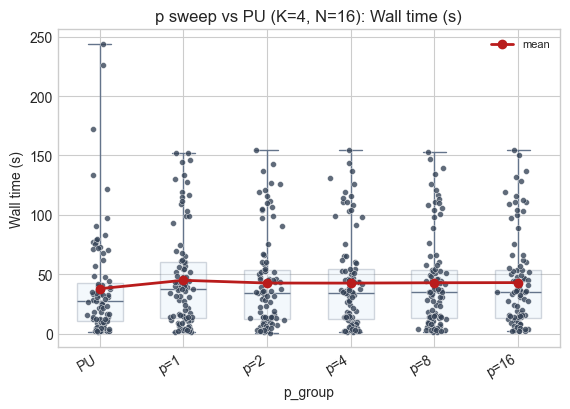

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/p_sweep_vs_PU_wall_memory_accuracy_peak_vram_gb.png


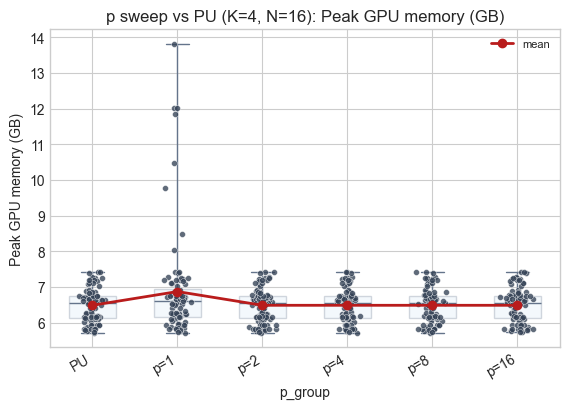

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/p_sweep_vs_PU_wall_memory_accuracy_drafter_accuracy.png


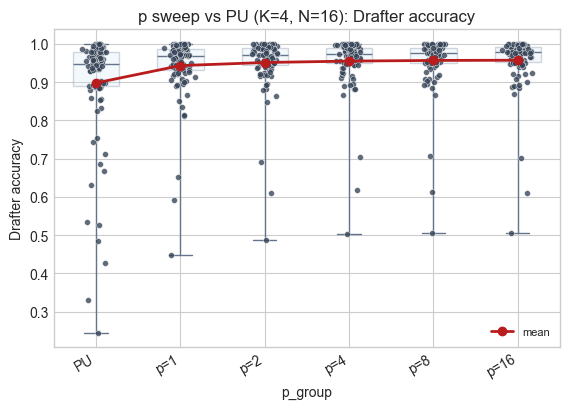

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/p_sweep_vs_PU_wall_memory_accuracy_acceptance_rate.png


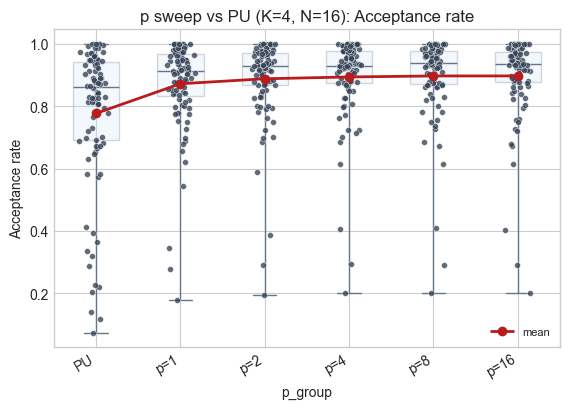

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/p_sweep_vs_PU_wall_memory_accuracy_exact_match_numeric.png


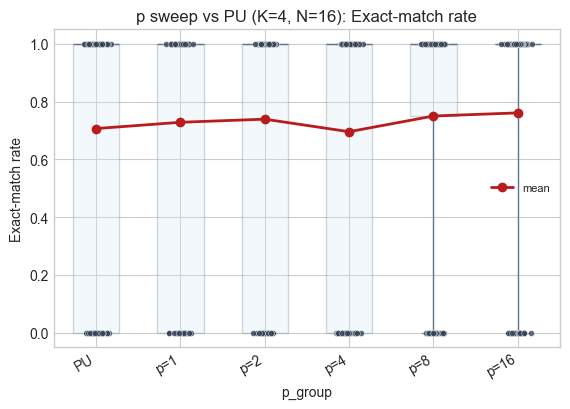

In [28]:
#@title p-parameter sweep vs static: wall time, memory, accuracy
P_SWEEP_K = 4
P_SWEEP_N = None  # None = choose most common prefix-sweep homolog count.

prefix_df = df_ok[df_ok['mode'].astype(str).eq('prefix')].copy()
if P_SWEEP_K is not None:
    prefix_df = prefix_df[prefix_df['K'].eq(P_SWEEP_K)].copy()

valid_n = prefix_df['n_homologs_requested'].dropna() if 'n_homologs_requested' in prefix_df else pd.Series(dtype=float)
if P_SWEEP_N is None and len(valid_n):
    P_SWEEP_N = int(valid_n.mode().iloc[0])
if P_SWEEP_N is not None:
    prefix_df = prefix_df[prefix_df['n_homologs_requested'].eq(P_SWEEP_N)].copy()

static_df = df_ok[df_ok['mode'].astype(str).eq('static')].copy()
if P_SWEEP_K is not None:
    static_df = static_df[static_df['K'].eq(P_SWEEP_K)].copy()
if P_SWEEP_N is not None:
    static_df = static_df[static_df['n_homologs_requested'].eq(P_SWEEP_N)].copy()

prefix_df['p_group'] = prefix_df['p'].apply(lambda x: f'p={int(x)}' if pd.notna(x) else 'prefix')
static_df['p_group'] = 'PU'
p_df = pd.concat([static_df, prefix_df], ignore_index=True)

valid_p = sorted(prefix_df['p'].dropna().unique()) if 'p' in prefix_df else []
p_group_order = ['PU'] + [f'p={int(x)}' for x in valid_p]

print('p-sweep prefix rows:', len(prefix_df))
print('static comparison rows:', len(static_df))
print('combined rows:', len(p_df))
print('combined proteins:', p_df['protein_id'].nunique() if len(p_df) else 0)
print('K:', P_SWEEP_K, 'N:', P_SWEEP_N)
print('groups:', p_group_order)

if len(prefix_df) == 0 or len(static_df) == 0 or not valid_p:
    print('No usable p-sweep/static comparison rows found. Check RESULT_CSV / filters.')
else:
    p_summary = summarize_by(p_df, 'p_group', PRIMARY_METRICS + ['acceptance_rate', 'exact_match_numeric'], group_order=p_group_order)
    p_summary_path = OUT_DIR / 'p_sweep_vs_PU_summary.csv'
    p_plot_path = OUT_DIR / 'p_sweep_vs_PU_wall_memory_accuracy.png'
    p_summary.to_csv(p_summary_path, index=False)
    p_mean_table = mean_value_table(p_df, 'p_group', PRIMARY_METRICS + ['acceptance_rate', 'exact_match_numeric'], group_order=p_group_order)
    print('proteins used for p sweep vs PU:', p_df['protein_id'].nunique())
    print('mean value table before plot:')
    display(p_mean_table)
    print('saved summary:', p_summary_path)
    plot_metric_grid(
        p_df,
        'p_group',
        PRIMARY_METRICS + ['acceptance_rate', 'exact_match_numeric'],
        f'p sweep vs PU (K={P_SWEEP_K}, N={P_SWEEP_N})',
        p_plot_path,
        group_order=p_group_order,
    )


homolog-sweep rows: 341
homolog-sweep proteins: 92
K: 4 mode: static
h values: [8, 16, 32, 64]
proteins used for homolog-count sweep: 92
mean value table before plot:


,n_homologs_requested,rows,proteins,mean_wall_s,mean_peak_vram_gb,mean_drafter_accuracy,mean_acceptance_rate,mean_exact_match_numeric
0,8,84,84,65.147651,6.430181,0.908344,0.791086,0.714286
1,16,92,92,37.769583,6.484450,0.897832,0.776861,0.706522
2,32,83,83,70.523168,6.425744,0.889003,0.757451,0.759036
3,64,82,82,72.399598,6.422318,0.891011,0.753302,0.756098


saved summary: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/homolog_count_summary.csv
saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/homolog_count_wall_memory_accuracy_wall_s.png


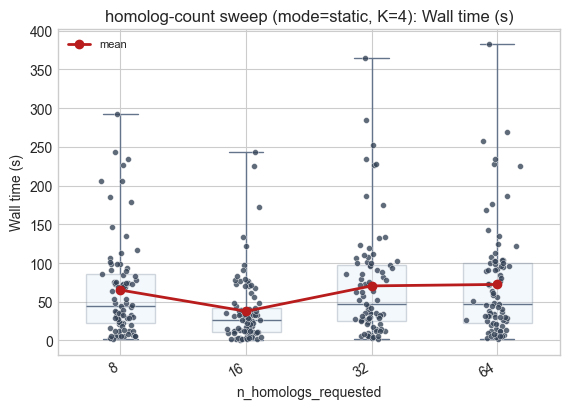

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/homolog_count_wall_memory_accuracy_peak_vram_gb.png


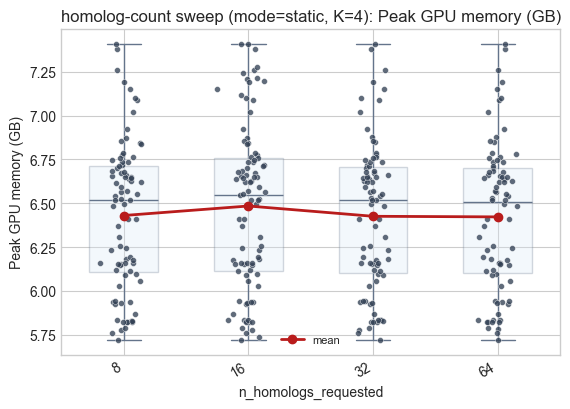

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/homolog_count_wall_memory_accuracy_drafter_accuracy.png


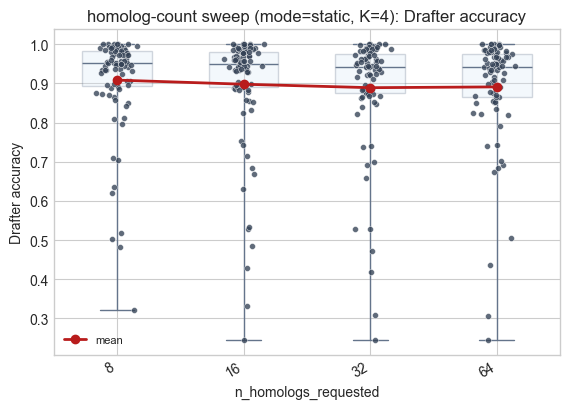

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/homolog_count_wall_memory_accuracy_acceptance_rate.png


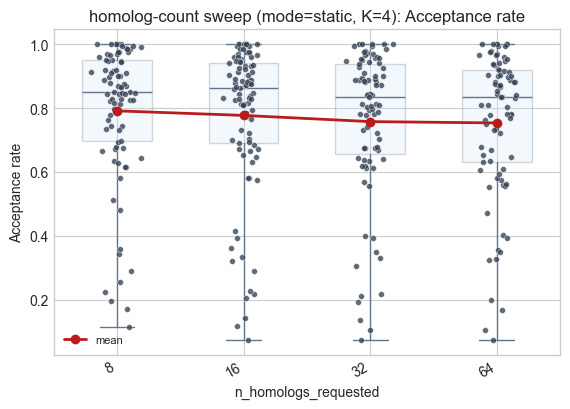

saved plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/homolog_count_wall_memory_accuracy_exact_match_numeric.png


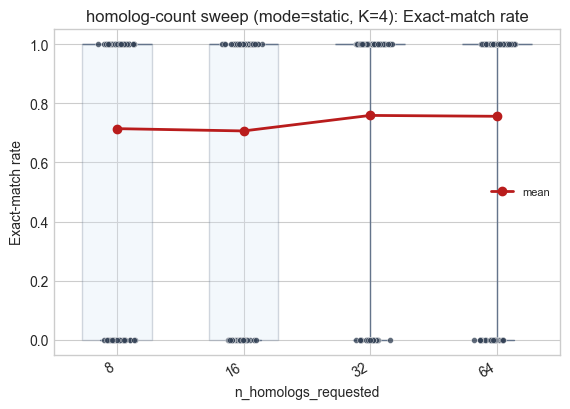

In [29]:
#@title Homolog-count sweep: wall time, memory, accuracy
HOMOLOG_SWEEP_K = 4
HOMOLOG_MODE = 'static'
H_VALUES = [8, 16, 32, 64]

h_df = df_ok[df_ok['mode'].astype(str).eq(HOMOLOG_MODE)].copy()
h_df = h_df[h_df['K'].eq(HOMOLOG_SWEEP_K)].copy()
h_df = h_df[h_df['n_homologs_requested'].isin(H_VALUES)].copy()
valid_h = sorted(h_df['n_homologs_requested'].dropna().unique()) if len(h_df) else []

print('homolog-sweep rows:', len(h_df))
print('homolog-sweep proteins:', h_df['protein_id'].nunique() if len(h_df) else 0)
print('K:', HOMOLOG_SWEEP_K, 'mode:', HOMOLOG_MODE)
print('h values:', [int(x) for x in valid_h] if valid_h else [])

if len(h_df) == 0 or not valid_h:
    print('No usable homolog-count sweep rows found. Run the static homolog-count benchmark first or check RESULT_CSV / filters.')
else:
    h_summary = summarize_by(h_df, 'n_homologs_requested', PRIMARY_METRICS + ['acceptance_rate', 'exact_match_numeric'])
    h_summary_path = OUT_DIR / 'homolog_count_summary.csv'
    h_plot_path = OUT_DIR / 'homolog_count_wall_memory_accuracy.png'
    h_summary.to_csv(h_summary_path, index=False)
    h_mean_table = mean_value_table(h_df, 'n_homologs_requested', PRIMARY_METRICS + ['acceptance_rate', 'exact_match_numeric'], group_order=H_VALUES)
    print('proteins used for homolog-count sweep:', h_df['protein_id'].nunique())
    print('mean value table before plot:')
    display(h_mean_table)
    print('saved summary:', h_summary_path)
    plot_metric_grid(h_df, 'n_homologs_requested', PRIMARY_METRICS + ['acceptance_rate', 'exact_match_numeric'], f'homolog-count sweep (mode={HOMOLOG_MODE}, K={HOMOLOG_SWEEP_K})', h_plot_path, group_order=H_VALUES)


saved combined plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/combined_stat_summary_p_sweep_wall_s.png


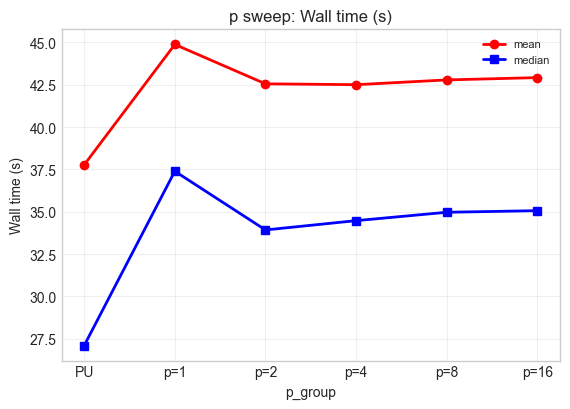

saved combined plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/combined_stat_summary_p_sweep_peak_vram_gb.png


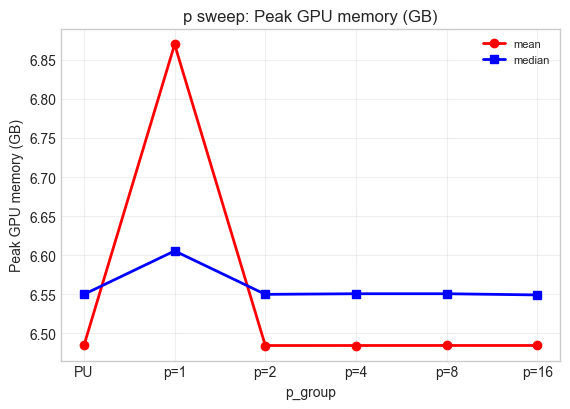

saved combined plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/combined_stat_summary_p_sweep_drafter_accuracy.png


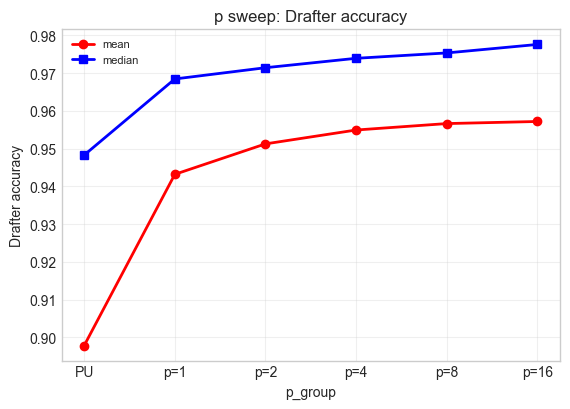

saved combined plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/combined_stat_summary_homolog_count_wall_s.png


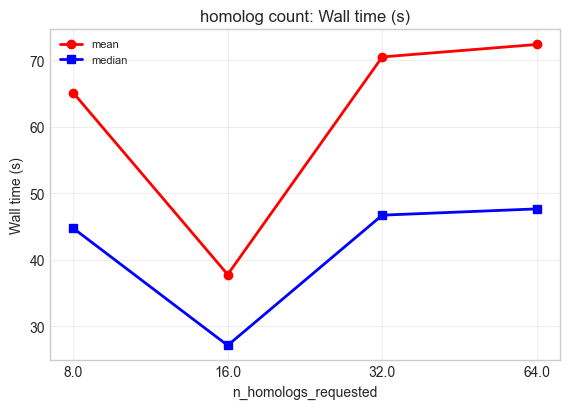

saved combined plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/combined_stat_summary_homolog_count_peak_vram_gb.png


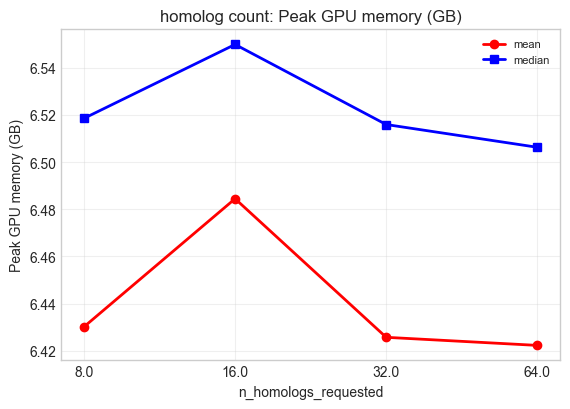

saved combined plot: /Users/chencheng-lin/Desktop/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5/prostT5/stat asset/combined_stat_summary_homolog_count_drafter_accuracy.png


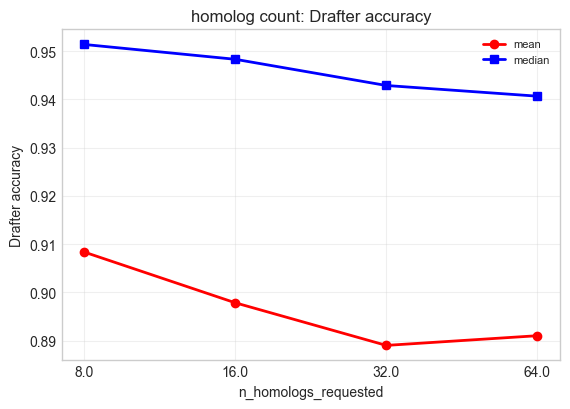

In [30]:
#@title Combined compact report figure
plot_specs = []
if 'p_df' in globals() and isinstance(p_df, pd.DataFrame) and len(p_df):
    plot_specs.append(('p_group', p_df, 'p sweep'))
if 'h_df' in globals() and isinstance(h_df, pd.DataFrame) and len(h_df):
    plot_specs.append(('n_homologs_requested', h_df, 'homolog count'))

metrics = _available_metrics(df_ok, PRIMARY_METRICS) if 'df_ok' in globals() else []
if not plot_specs or not metrics:
    print('Nothing to combine yet.')
else:
    for group_col, frame, row_title in plot_specs:
        if group_col == 'p_group' and 'p_group_order' in globals():
            x_values = [x for x in p_group_order if x in set(frame[group_col].dropna().unique())]
        else:
            x_values = sorted(frame[group_col].dropna().unique())
        if not x_values:
            print(f'No {group_col} values for {row_title}.')
            continue
        for metric in metrics:
            if metric not in frame.columns or not frame[metric].notna().any():
                print(f'No {metric} for {row_title}.')
                continue
            fig, ax = plt.subplots(figsize=(5.8, 4.2))
            summary = frame.dropna(subset=[group_col, metric]).groupby(group_col)[metric].agg(['mean', 'median']).reindex(x_values)
            ax.plot(range(len(x_values)), summary['mean'], color='red', marker='o', linewidth=2, label='mean')
            ax.plot(range(len(x_values)), summary['median'], color='blue', marker='s', linewidth=2, label='median')
            ax.set_xticks(range(len(x_values)))
            ax.set_xticklabels([str(x) for x in x_values])
            ax.set_title(f'{row_title}: {METRICS.get(metric, metric)}')
            ax.set_xlabel(group_col)
            ax.set_ylabel(METRICS.get(metric, metric))
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            combined_path = OUT_DIR / f'combined_stat_summary_{_slug_filename(row_title)}_{_slug_filename(metric)}.png'
            fig.savefig(combined_path, dpi=220, bbox_inches='tight')
            print('saved combined plot:', combined_path)
            plt.show()
